In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import shutil
import tensorflow as tf
import joblib

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2026-03-01 13:00:33.415567: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772370033.767021      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772370033.864115      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772370034.752815      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772370034.753001      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772370034.753006      55 computation_placer.cc:177] computation placer alr

/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/yield_scaler.pkl
/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/rice_yield_model_final.pkl
/kaggle/input/models/sanilawijesekara/yield-pca/scikitlearn/default/1/rice_yield_pca_v7.pkl
/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/lstm_scaler.joblib
/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/district_encoder.joblib
/kaggle/input/models/sanilawijesekara/ricevision-v7/tensorflow2/default/1/ricevision_v7_district_aware.keras
/kaggle/input/datasets/sanilawijesekara/yield-baselines/yield_training_preprocessed.csv
/kaggle/input/datasets/sanilawijesekara/lstm-dataframes-for-yield/Inference_preprocessed.csv
/kaggle/input/datasets/sanilawijesekara/lstm-dataframes-for-yield/lstm_resuls.csv


In [2]:
work_dir = "/kaggle/working"

for filename in os.listdir(work_dir):
    file_path = os.path.join(work_dir, filename)
    if os.path.isfile(file_path) or os.path.islink(file_path):
        os.unlink(file_path)
    elif os.path.isdir(file_path):
        shutil.rmtree(file_path)

print("Output directory cleaned!")

Output directory cleaned!


# Loading lstm results datasets and preprocessed datasets

In [3]:
df_inference_preprocessed = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/lstm-dataframes-for-yield/Inference_preprocessed.csv")
df_lstm_results = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/lstm-dataframes-for-yield/lstm_resuls.csv")

# Defining models, feature extractor and scalers

In [4]:
# ==========================================
# 1. SETUP & MODEL LOADING
# ==========================================
print("📂 Loading Models and Scalers...")

# Scalers & PCA
main_scaler = joblib.load("/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/lstm_scaler.joblib")
yield_scaler = joblib.load("/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/yield_scaler.pkl")
pca = joblib.load("/kaggle/input/models/sanilawijesekara/yield-pca/scikitlearn/default/1/rice_yield_pca_v7.pkl")

# Yield Prediction Model
lasso_yield_model = joblib.load("/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/rice_yield_model_final.pkl")

# LSTM Feature Extractor
model_path = '/kaggle/input/models/sanilawijesekara/ricevision-v7/tensorflow2/default/1/ricevision_v7_district_aware.keras'
lstm_model = tf.keras.models.load_model(model_path, compile=False)
feature_extractor = tf.keras.Model(
    inputs=lstm_model.input,
    outputs=lstm_model.get_layer('dense_1').output
)

# Feature Lists
base_ts = ['ndvi_median_smooth', 'lswi_median_smooth', 'evi_median_smooth', 'ndwi_median_smooth', 
           'bsi_median_smooth', 'ndvi_vel_z', 'lswi_vel_z', 'bsi_z', 'ndvi_zscore', 
           'rain_7d_mean', 'rain_14d_mean', 'tmean_mean', 'rh_mean_mean', 'delta_days', 
           'doy_sin', 'doy_cos', 'is_growing']
hazard_cols = ['hazard_drought', 'hazard_flood', 'hazard_heavy_rain', 'hazard_landslide', 'hazard_lightning', 'hazard_wind']
ts_features = base_ts + hazard_cols + ['flood_index', 'ndvi_delta']
static_features = ['lat', 'lon', 'elevation', 'slope', 'season_id', 'doy_sin', 'doy_cos']

📂 Loading Models and Scalers...


2026-03-01 13:01:13.591193: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
df_inference_preprocessed.head()

,pixel_id,date,year,stage_name,month,season,season_id,cycle_id,ndvi_median_smooth,lswi_median_smooth,...,cpi,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind,flood_index,ndvi_delta,is_growing
0,0,2025-10-15,2025,Transplant,10,Maha,0,2025_2026_Maha,-0.857947,-1.031677,...,-0.156633,0,0,0,0,0,0,-0.173730,0.000000,0.0
1,0,2025-10-30,2025,Transplant,10,Maha,0,2025_2026_Maha,-0.667449,-0.868776,...,-0.514367,0,0,0,0,0,0,-0.201327,0.190499,0.0
2,0,2025-11-14,2025,Vegetative,11,Maha,0,2025_2026_Maha,-0.429452,-0.661881,...,1.657635,0,0,0,0,0,0,-0.232428,0.237997,1.0
3,0,2025-11-29,2025,Vegetative,11,Maha,0,2025_2026_Maha,0.090810,-0.437434,...,1.442566,0,0,0,0,0,0,-0.528244,0.520263,1.0
4,0,2025-12-14,2025,Ripening,12,Maha,0,2025_2026_Maha,-0.431033,-0.033515,...,1.279291,0,0,0,0,0,0,0.397518,-0.521843,1.0


# Loading yield baselines

In [6]:
df_yield_baselines = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/yield-baselines/yield_training_preprocessed.csv")
df_yield_baselines.head()

,veg_days,repro_days,peak_health,auc_health,avg_health,temp_flowering,rain_flowering,stress_flowering,PC1,PC2,...,PC5,Average_yield_kg_per_ha,Season_ID,District_ID,heat_stress_combo,health_per_day,district_historical_avg,heat_rain_ratio,repro_efficiency,crisis_year
0,106.539232,54.752582,0.901939,6.842034,-0.021292,-0.847574,0.059095,0.603515,2.417265,-0.994216,...,0.825333,2857,0,0,-0.511523,0.042420,4067.857143,-0.731238,0.122721,1
1,64.594595,50.125707,0.945928,4.352596,-0.039154,0.235582,-0.092422,0.658077,-1.675339,4.332715,...,1.030039,3708,1,0,0.155031,0.037941,4067.857143,0.233810,0.085135,1
2,222.591554,124.489637,1.381839,14.947866,-0.006680,-0.897823,0.130170,1.399252,2.949106,-2.182027,...,-0.128902,4172,0,0,-1.256281,0.043067,4067.857143,-0.729837,0.119116,0
3,133.217257,82.779661,1.332580,9.916422,0.024450,1.125715,-0.379825,1.045609,-1.416977,-3.480458,...,0.079124,4338,1,0,1.177058,0.045910,4067.857143,1.563114,0.118363,0
4,248.327677,145.692687,1.476648,16.849490,-0.003016,-0.932013,0.204954,1.580994,3.124729,-2.841823,...,-0.292757,3933,0,0,-1.473507,0.042763,4067.857143,-0.714212,0.114863,0


# Drop stage and stage_name from preprocessed dataset

In [7]:
df_inference_preprocessed.drop(columns=['stage_name','stage'], inplace=True)

In [8]:
df_inference_preprocessed.head()

,pixel_id,date,year,month,season,season_id,cycle_id,ndvi_median_smooth,lswi_median_smooth,evi_median_smooth,...,cpi,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind,flood_index,ndvi_delta,is_growing
0,0,2025-10-15,2025,10,Maha,0,2025_2026_Maha,-0.857947,-1.031677,-0.739666,...,-0.156633,0,0,0,0,0,0,-0.173730,0.000000,0.0
1,0,2025-10-30,2025,10,Maha,0,2025_2026_Maha,-0.667449,-0.868776,-0.678032,...,-0.514367,0,0,0,0,0,0,-0.201327,0.190499,0.0
2,0,2025-11-14,2025,11,Maha,0,2025_2026_Maha,-0.429452,-0.661881,-0.612608,...,1.657635,0,0,0,0,0,0,-0.232428,0.237997,1.0
3,0,2025-11-29,2025,11,Maha,0,2025_2026_Maha,0.090810,-0.437434,-0.554540,...,1.442566,0,0,0,0,0,0,-0.528244,0.520263,1.0
4,0,2025-12-14,2025,12,Maha,0,2025_2026_Maha,-0.431033,-0.033515,-0.487543,...,1.279291,0,0,0,0,0,0,0.397518,-0.521843,1.0


In [9]:
df_inference_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292280 entries, 0 to 292279
Data columns (total 38 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   pixel_id            292280 non-null  int64  
 1   date                292280 non-null  object 
 2   year                292280 non-null  int64  
 3   month               292280 non-null  int64  
 4   season              292280 non-null  object 
 5   season_id           292280 non-null  int64  
 6   cycle_id            292280 non-null  object 
 7   ndvi_median_smooth  292280 non-null  float64
 8   lswi_median_smooth  292280 non-null  float64
 9   evi_median_smooth   292280 non-null  float64
 10  ndwi_median_smooth  292280 non-null  float64
 11  bsi_median_smooth   292280 non-null  float64
 12  ndvi_vel_z          292280 non-null  float64
 13  lswi_vel_z          292280 non-null  float64
 14  rain_7d_mean        292280 non-null  float64
 15  rain_14d_mean       292280 non-nul

In [10]:
df_lstm_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29228 entries, 0 to 29227
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pixel_id             29228 non-null  int64  
 1   date                 29228 non-null  object 
 2   district_id          29228 non-null  int64  
 3   is_growing           29228 non-null  float64
 4   pred_stage_id        29228 non-null  int64  
 5   pred_health_z        29228 non-null  float64
 6   pred_pest_cpi        29228 non-null  float64
 7   final_health_impact  29228 non-null  float64
 8   final_pest_impact    29228 non-null  float64
 9   pred_stage_name      29228 non-null  object 
 10  district             29228 non-null  object 
 11  health_category      29228 non-null  object 
 12  pest_flag            29228 non-null  int64  
 13  lat                  29228 non-null  float64
 14  lon                  29228 non-null  float64
dtypes: float64(7), int64(4), object(4)
m

In [11]:
df_lstm_results['district'].unique()

array(['Puttalam', 'Jaffna', 'Colombo', 'Gampaha', 'Kurunegala',
       'Kaluthara', 'Mannar', 'Kilinochchi', 'Galle', 'Anuradhapura',
       'Vavuniya', 'Kegalle', 'Mullaitivu', 'Ratnapura', 'Matara',
       'Kandy', 'Nuwara Eliya', 'Matale', 'Hambantota', 'Trincomalee',
       'Polonnaruwa', 'Monaragala', 'Ampara', 'Badulla', 'Batticaloa'],
      dtype=object)

# Performing standard scaling using lstm scaler

In [12]:
main_scaler = joblib.load("/kaggle/input/models/sanilawijesekara/encoder-scaler/scikitlearn/default/1/lstm_scaler.joblib") 

In [13]:
# ==========================================
# 2. STEP 1: LIVE STANDARD SCALING (Bypass)
# ==========================================
print("⚖️ Performing Live Standard Scaling (Bypassing Main Scaler)...")
df_z = df_inference_preprocessed.copy()

# List of all features the LSTM and PCA need
all_features_to_scale = list(set(ts_features + static_features + main_scaler.feature_names_in_.tolist()))

for col in all_features_to_scale:
    if col in df_z.columns:
        # Standardize: (Value - Mean) / Std
        col_mean = df_z[col].mean()
        col_std = df_z[col].std() + 1e-6 # Avoid division by zero
        
        df_z[col] = (df_z[col] - col_mean) / col_std

# Final check: Every mean MUST be 0.000000
print("📊 Mean of LSTM inputs (Should be EXACTLY 0):")
print(df_z[ts_features].mean().head(60))

⚖️ Performing Live Standard Scaling (Bypassing Main Scaler)...
📊 Mean of LSTM inputs (Should be EXACTLY 0):
ndvi_median_smooth   -8.518345e-17
lswi_median_smooth   -1.299145e-16
evi_median_smooth    -3.189517e-17
ndwi_median_smooth    1.680331e-16
bsi_median_smooth    -1.042428e-16
ndvi_vel_z           -2.022621e-17
lswi_vel_z            3.111724e-18
bsi_z                 7.779310e-18
ndvi_zscore          -3.111724e-18
rain_7d_mean         -2.499103e-17
rain_14d_mean        -1.031974e-16
tmean_mean           -2.380469e-16
rh_mean_mean         -1.260248e-16
delta_days           -3.940889e-16
doy_sin              -1.309872e-17
doy_cos              -1.956375e-16
is_growing           -2.956138e-17
hazard_drought        0.000000e+00
hazard_flood          1.079379e-17
hazard_heavy_rain    -1.628793e-18
hazard_landslide     -5.883103e-18
hazard_lightning     -5.251034e-18
hazard_wind          -1.653103e-17
flood_index           5.445517e-17
ndvi_delta            6.067862e-17
dtype: float64


# Extracting latents for PCA

In [14]:
# ==========================================
# 3. EXTRACT LATENTS & PCA
# ==========================================
def create_lstm_inputs(df, window_size=10):
    df = df.sort_values(['pixel_id', 'date']).reset_index(drop=True)
    df['group_id'] = df.groupby(['pixel_id', 'cycle_id']).ngroup()
    
    ts_data = df[ts_features].values.astype('float32')
    st_data = df[static_features].values.astype('float32')
    di_data = df['district_id'].values.astype('int32')
    group_ids = df['group_id'].values
    
    starts = np.arange(len(df) - window_size + 1)
    ends = starts + window_size - 1
    valid_mask = (group_ids[starts] == group_ids[ends])
    v_starts, v_ends = starts[valid_mask], ends[valid_mask]
    indices = v_starts[:, None] + np.arange(window_size)[None, :]
    
    return {"temporal_input": ts_data[indices], "static_input": st_data[v_ends], "district_input": di_data[v_ends]}, v_ends

X_input, valid_indices = create_lstm_inputs(df_z)
latents = feature_extractor.predict(X_input, batch_size=1024)

29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 461ms/step


In [15]:
X_input

{'temporal_input': array([[[-6.06075004e-02, -1.50089383e+00, -5.76343954e-01, ...,
          -4.49350998e-02, -9.44441199e-01, -1.34388655e-01],
         [ 7.98247010e-02, -1.33369720e+00, -5.35428166e-01, ...,
          -4.49350998e-02, -9.63326573e-01,  2.94999778e-01],
         [ 2.55271584e-01, -1.12134647e+00, -4.91995901e-01, ...,
          -4.49350998e-02, -9.84609663e-01,  4.02061403e-01],
         ...,
         [-1.71075308e+00,  4.93819475e-01, -5.37643147e+00, ...,
          -4.49350998e-02,  1.91732049e+00, -4.82344389e-01],
         [-1.78665245e+00,  5.44795036e-01, -7.07349443e+00, ...,
          -4.49350998e-02,  2.02176428e+00, -3.66459787e-01],
         [-1.69861484e+00,  4.94902104e-01, -7.82091570e+00, ...,
          -4.49350998e-02,  1.90677452e+00,  1.34796783e-01]],
 
        [[-1.16604939e-01, -1.52933955e+00, -5.93486011e-01, ...,
          -4.49350998e-02, -9.11425292e-01, -1.34388655e-01],
         [-1.20407239e-01, -1.46306670e+00, -6.81476474e-01, ...,
   

In [16]:
valid_indices

array([     9,     19,     29, ..., 292259, 292269, 292279])

# Applying PCA for latents

In [17]:
print("📉 Applying PCA...")
pc_features = pca.transform(latents)
# CRITICAL: We force PCs to stay within the range the Lasso model expects (-5 to 5)
pc_features = np.clip(pc_features, -5, 5) 

df_master_z = df_z.iloc[valid_indices].copy()
for i in range(5):
    df_master_z[f'PC{i+1}'] = pc_features[:, i]
df_master_z = df_master_z.merge(
    df_lstm_results[['pixel_id', 'date', 'pred_stage_id', 'pred_health_z']], 
    on=['pixel_id', 'date'], how='left'
)

📉 Applying PCA...


# Adding necessary features to predict average yield from lstm results and making district summary

In [18]:
# ==========================================
# 4. Z-TO-Z BLENDING
# ==========================================
padding_lookup_z = df_yield_baselines.groupby('District_ID').mean().to_dict('index')

def summarize_z_blended(group):
    district_id = int(group['district_id'].iloc[0])
    ref = padding_lookup_z.get(district_id, next(iter(padding_lookup_z.values())))
    
    real_weight = len(group) / 12.0 
    hist_weight = 1.0 - real_weight
    
    # Mathematical Z-blending: ensures values stay in -3 to 3 range
    avg_h = (group['ndvi_median_smooth'].mean() * real_weight) + (ref['avg_health'] * hist_weight)
    temp_f = (group['tmean_mean'].mean() * real_weight) + (ref['temp_flowering'] * hist_weight)
    rain_f = (group['rain_7d_mean'].mean() * real_weight) + (ref['rain_flowering'] * hist_weight)
    
    return pd.Series({
        'veg_days': ref['veg_days'],
        'repro_days': ref['repro_days'],
        'peak_health': max(group['ndvi_median_smooth'].max(), ref['peak_health']),
        'avg_health': avg_h,
        'auc_health': avg_h * 12, 
        'temp_flowering': temp_f,
        'rain_flowering': rain_f,
        'stress_flowering': (group['pred_health_z'] < -1.0).mean() if (group['pred_stage_id']==2).any() else ref['stress_flowering'],
        'PC1': group['PC1'].iloc[-1], 'PC2': group['PC2'].iloc[-1], 'PC3': group['PC3'].iloc[-1],
        'PC4': group['PC4'].iloc[-1], 'PC5': group['PC5'].iloc[-1],
        'Season_ID': 1 if group['season'].iloc[0] == 'Yala' else 0,
        'District_ID': district_id,
        'district_historical_avg': ref['Average_yield_kg_per_ha']
    })

print("🌱 Summarizing pixels...")
pixel_stats = df_master_z.groupby('pixel_id').apply(summarize_z_blended).reset_index()
district_summary = pixel_stats.groupby(['District_ID', 'Season_ID']).mean().reset_index()

🌱 Summarizing pixels...


/tmp/ipykernel_55/3260613597.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pixel_stats = df_master_z.groupby('pixel_id').apply(summarize_z_blended).reset_index()


# Feature engineering and deriving features

In [19]:
# ==========================================
# 5. FEATURE ENGINEERING & FINAL PREDICTION
# ==========================================
# 5.1 Map Historical Data correctly
district_lookup = df_yield_baselines.groupby('District_ID')['Average_yield_kg_per_ha'].mean().to_dict()
global_avg_yield = df_yield_baselines['Average_yield_kg_per_ha'].mean()
district_summary['District_ID'] = district_summary['District_ID'].astype(int)
district_summary['district_historical_avg'] = district_summary['District_ID'].map(district_lookup).fillna(global_avg_yield)

# Derived Features
district_summary['heat_stress_combo'] = district_summary['temp_flowering'] * district_summary['stress_flowering']
district_summary['health_per_day'] = district_summary['auc_health'] / (district_summary['veg_days'] + district_summary['repro_days'] + 1)
# 4. Final Feature Engineering (Must match 'expected_features' order)
district_summary['heat_rain_ratio'] = district_summary['temp_flowering'] / (district_summary['rain_flowering'] + 2)
district_summary['repro_efficiency'] = district_summary['avg_health'] * district_summary['repro_days']
district_summary['crisis_year'] = 0

In [20]:
district_summary

,District_ID,Season_ID,pixel_id,veg_days,repro_days,peak_health,avg_health,auc_health,temp_flowering,rain_flowering,...,PC2,PC3,PC4,PC5,district_historical_avg,heat_stress_combo,health_per_day,heat_rain_ratio,repro_efficiency,crisis_year
0,0,0.0,25993.671846,148.630482,86.430850,1.388189,0.089555,1.074657,-0.235894,-0.066687,...,4.771617,0.154662,0.389689,-1.140771,4067.857143,-0.069994,0.004552,-0.122015,7.740295,0
1,1,0.0,9829.690466,127.680873,75.232171,1.105799,-0.107272,-1.287262,-0.229424,-0.075819,...,-4.213744,-0.002688,0.122751,1.127023,4005.000000,-0.194957,-0.006313,-0.119232,-8.070291,0
2,2,0.0,18711.000000,349.460790,170.077660,1.846548,0.154432,1.853189,-0.529490,-0.064954,...,-2.043479,2.915234,-1.986964,-2.300409,4007.285714,-1.120740,0.003560,-0.273632,26.265500,0
3,3,0.0,25020.186456,149.026404,86.688719,1.309594,0.076033,0.912396,-0.214296,-0.069436,...,4.474282,0.765872,1.752577,-1.909680,2822.714286,-0.049696,0.003854,-0.111002,6.591203,0
4,4,0.0,1519.618182,364.075491,162.865174,1.656365,0.107202,1.286421,-0.313965,-0.059790,...,0.332783,3.392843,-1.815184,0.833329,2600.142857,-0.438859,0.002437,-0.161820,17.459434,0
5,5,0.0,5061.302632,365.535821,164.254034,1.708317,0.122950,1.475404,-0.370541,-0.042011,...,-0.495225,3.601349,-2.512150,0.391596,2616.142857,-0.758433,0.002780,-0.189246,20.195082,0
6,6,0.0,1800.854093,340.547880,167.465747,1.555925,0.027199,0.326388,-0.286863,-0.074524,...,-0.992998,3.172988,-1.058298,0.645564,2948.142857,-0.507363,0.000641,-0.148983,4.554908,0
7,7,0.0,18062.665245,242.616807,131.096433,1.621336,0.106194,1.274322,-0.229640,-0.092378,...,4.308539,3.190935,-1.124573,0.298553,5130.000000,-0.193364,0.003401,-0.120380,13.921592,0
8,8,0.0,2911.368620,407.705190,197.339398,1.568635,-0.061689,-0.740267,-0.853287,0.110966,...,2.639196,-0.193025,-1.469134,1.139812,2500.500000,-1.629783,-0.001221,-0.404216,-12.173651,0
9,9,0.0,2823.300699,355.259740,169.507257,1.719864,0.124423,1.493077,-0.364541,-0.052033,...,0.455074,4.341405,-2.280712,-0.260128,3429.857143,-0.446185,0.002840,-0.187139,21.090612,0


In [21]:
district_summary

,District_ID,Season_ID,pixel_id,veg_days,repro_days,peak_health,avg_health,auc_health,temp_flowering,rain_flowering,...,PC2,PC3,PC4,PC5,district_historical_avg,heat_stress_combo,health_per_day,heat_rain_ratio,repro_efficiency,crisis_year
0,0,0.0,25993.671846,148.630482,86.430850,1.388189,0.089555,1.074657,-0.235894,-0.066687,...,4.771617,0.154662,0.389689,-1.140771,4067.857143,-0.069994,0.004552,-0.122015,7.740295,0
1,1,0.0,9829.690466,127.680873,75.232171,1.105799,-0.107272,-1.287262,-0.229424,-0.075819,...,-4.213744,-0.002688,0.122751,1.127023,4005.000000,-0.194957,-0.006313,-0.119232,-8.070291,0
2,2,0.0,18711.000000,349.460790,170.077660,1.846548,0.154432,1.853189,-0.529490,-0.064954,...,-2.043479,2.915234,-1.986964,-2.300409,4007.285714,-1.120740,0.003560,-0.273632,26.265500,0
3,3,0.0,25020.186456,149.026404,86.688719,1.309594,0.076033,0.912396,-0.214296,-0.069436,...,4.474282,0.765872,1.752577,-1.909680,2822.714286,-0.049696,0.003854,-0.111002,6.591203,0
4,4,0.0,1519.618182,364.075491,162.865174,1.656365,0.107202,1.286421,-0.313965,-0.059790,...,0.332783,3.392843,-1.815184,0.833329,2600.142857,-0.438859,0.002437,-0.161820,17.459434,0
5,5,0.0,5061.302632,365.535821,164.254034,1.708317,0.122950,1.475404,-0.370541,-0.042011,...,-0.495225,3.601349,-2.512150,0.391596,2616.142857,-0.758433,0.002780,-0.189246,20.195082,0
6,6,0.0,1800.854093,340.547880,167.465747,1.555925,0.027199,0.326388,-0.286863,-0.074524,...,-0.992998,3.172988,-1.058298,0.645564,2948.142857,-0.507363,0.000641,-0.148983,4.554908,0
7,7,0.0,18062.665245,242.616807,131.096433,1.621336,0.106194,1.274322,-0.229640,-0.092378,...,4.308539,3.190935,-1.124573,0.298553,5130.000000,-0.193364,0.003401,-0.120380,13.921592,0
8,8,0.0,2911.368620,407.705190,197.339398,1.568635,-0.061689,-0.740267,-0.853287,0.110966,...,2.639196,-0.193025,-1.469134,1.139812,2500.500000,-1.629783,-0.001221,-0.404216,-12.173651,0
9,9,0.0,2823.300699,355.259740,169.507257,1.719864,0.124423,1.493077,-0.364541,-0.052033,...,0.455074,4.341405,-2.280712,-0.260128,3429.857143,-0.446185,0.002840,-0.187139,21.090612,0


In [22]:
district_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   District_ID              25 non-null     int64  
 1   Season_ID                25 non-null     float64
 2   pixel_id                 25 non-null     float64
 3   veg_days                 25 non-null     float64
 4   repro_days               25 non-null     float64
 5   peak_health              25 non-null     float64
 6   avg_health               25 non-null     float64
 7   auc_health               25 non-null     float64
 8   temp_flowering           25 non-null     float64
 9   rain_flowering           25 non-null     float64
 10  stress_flowering         25 non-null     float64
 11  PC1                      25 non-null     float64
 12  PC2                      25 non-null     float64
 13  PC3                      25 non-null     float64
 14  PC4                      25 

In [23]:
df_yield_baselines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   veg_days                 165 non-null    float64
 1   repro_days               165 non-null    float64
 2   peak_health              165 non-null    float64
 3   auc_health               165 non-null    float64
 4   avg_health               165 non-null    float64
 5   temp_flowering           165 non-null    float64
 6   rain_flowering           165 non-null    float64
 7   stress_flowering         165 non-null    float64
 8   PC1                      165 non-null    float64
 9   PC2                      165 non-null    float64
 10  PC3                      165 non-null    float64
 11  PC4                      165 non-null    float64
 12  PC5                      165 non-null    float64
 13  Average_yield_kg_per_ha  165 non-null    int64  
 14  Season_ID                1

# Visualizing distributions and boxplots

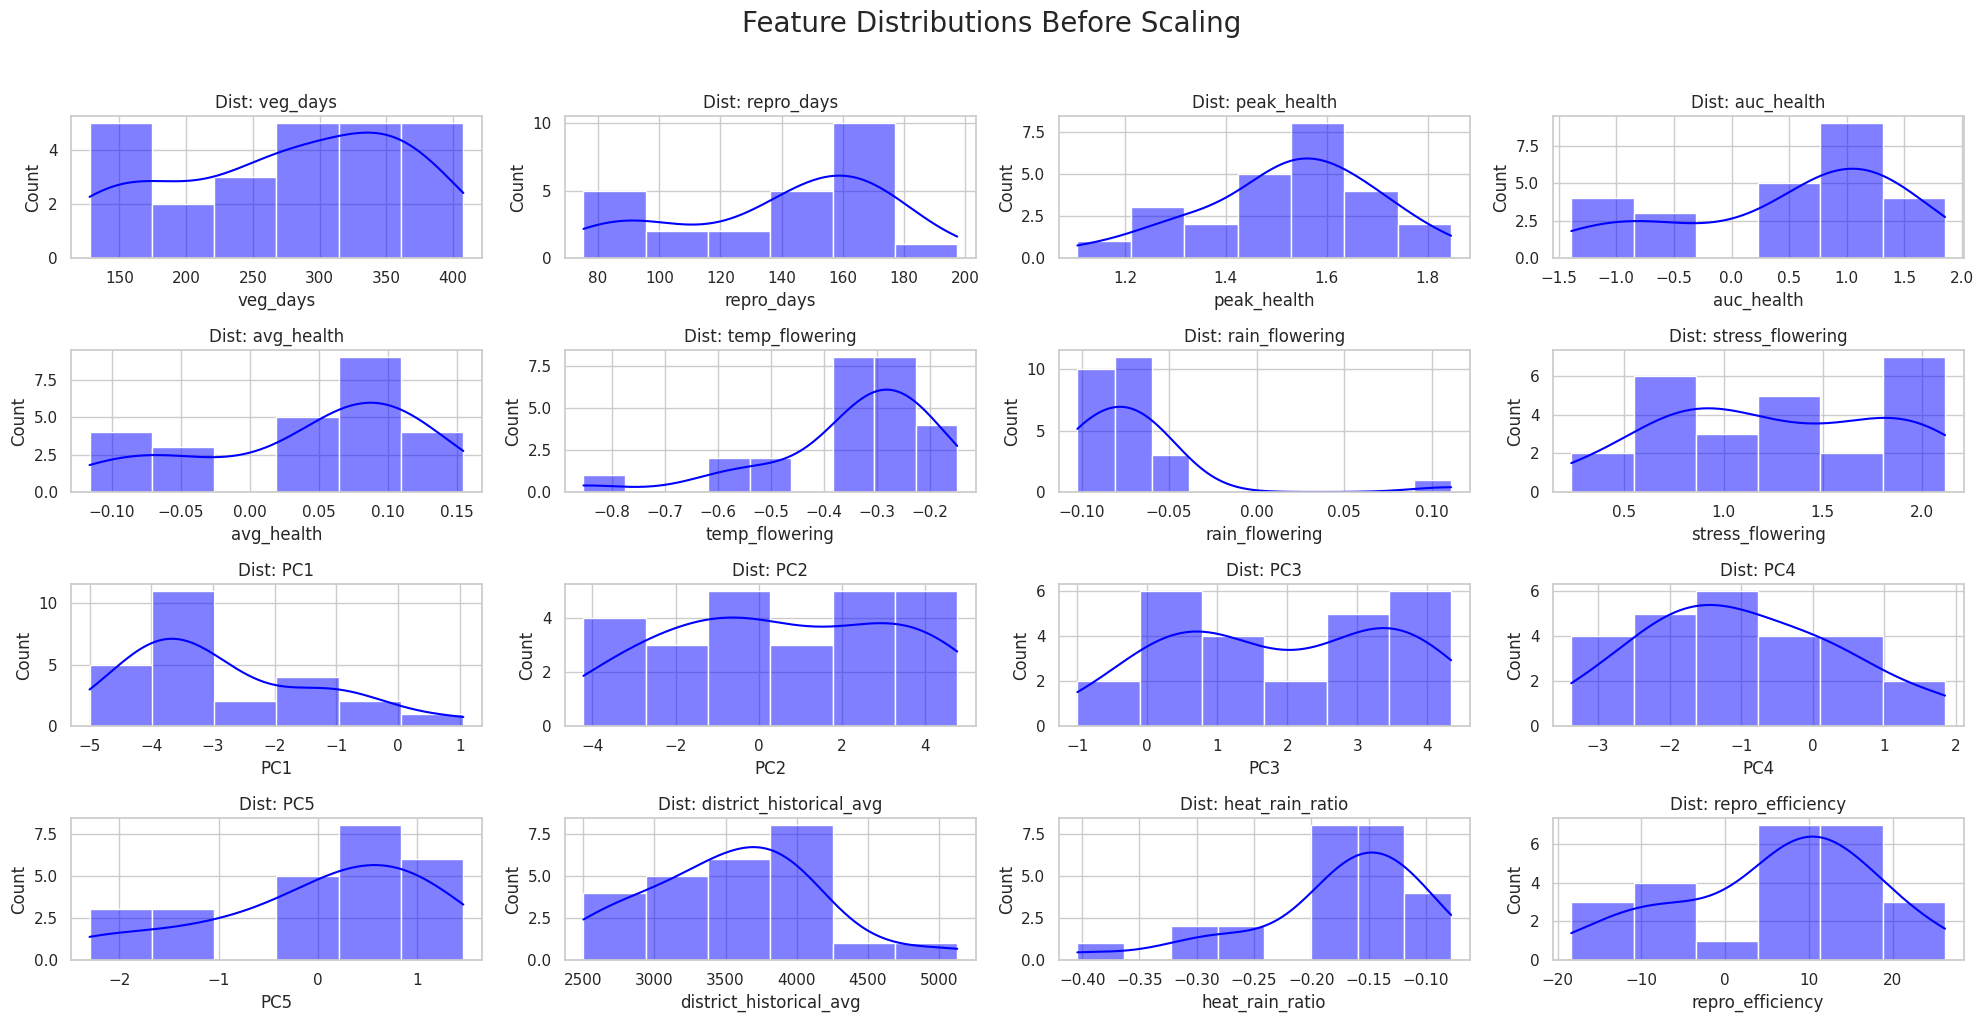

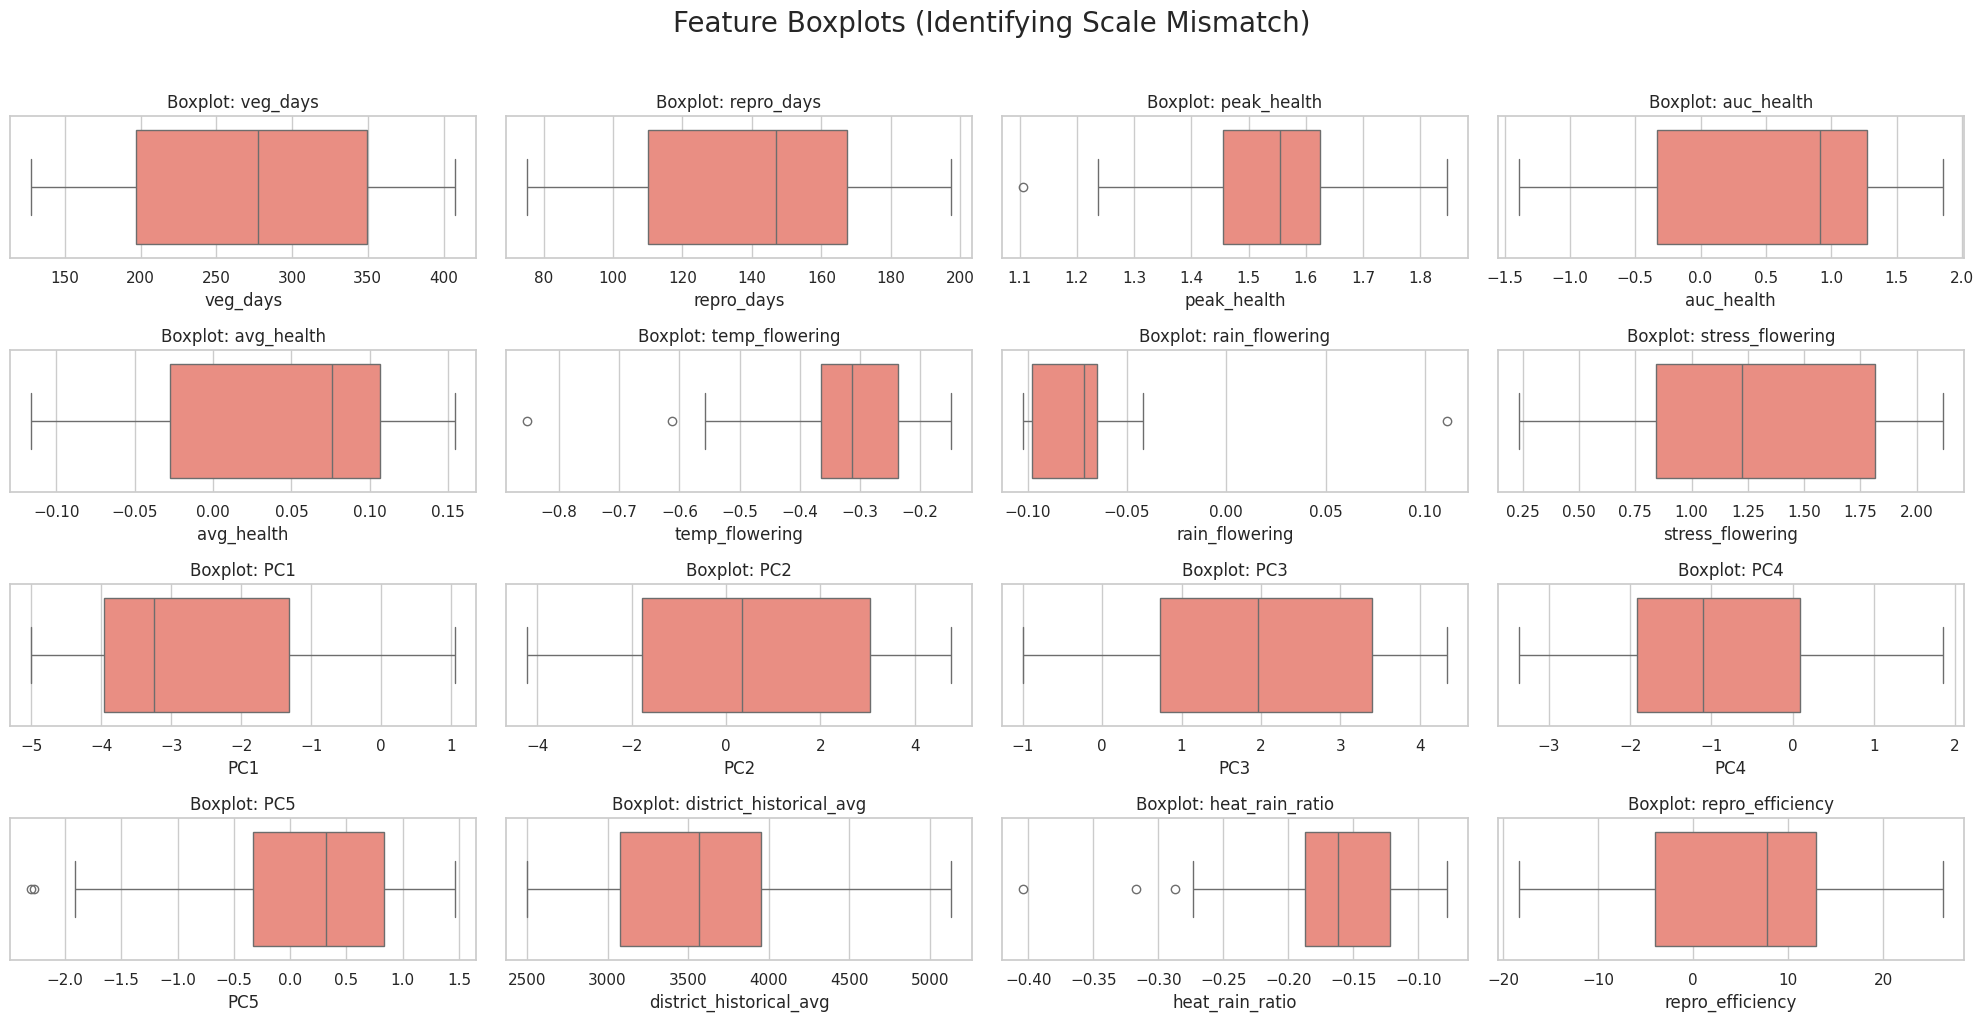

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

#Define the features you want to visualize
features_to_plot = [
    'veg_days', 'repro_days', 'peak_health', 'auc_health', 'avg_health', 
    'temp_flowering', 'rain_flowering', 'stress_flowering', 'PC1', 'PC2', 
    'PC3', 'PC4', 'PC5', 'district_historical_avg', 'heat_rain_ratio', 
    'repro_efficiency'
]
# Set the style
sns.set(style="whitegrid")

# 1. DISTRIBUTION PLOTS (Histograms)
plt.figure(figsize=(20, 10))
plt.suptitle("Feature Distributions Before Scaling", fontsize=20, y=1.02)

for i, col in enumerate(features_to_plot):
    plt.subplot(4, 4, i + 1)
    sns.histplot(district_summary[col], kde=True, color="blue")
    plt.title(f'Dist: {col}')
    plt.tight_layout()

plt.show()

# 2. BOXPLOTS (To see Scale and Outliers)
plt.figure(figsize=(20, 10))
plt.suptitle("Feature Boxplots (Identifying Scale Mismatch)", fontsize=20, y=1.02)

for i, col in enumerate(features_to_plot):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=district_summary[col], color="salmon")
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()

plt.show()

# Scaling using yield scaler and getting predictions

In [25]:
# ==========================================
# 5. FINAL PREDICTION (With Heuristic Calibration)
# ==========================================
lasso_features = lasso_yield_model.feature_names_in_.tolist()

# 1. Standard Scaling & Shield
X_final_raw = district_summary[lasso_features].fillna(0)
X_final_scaled = yield_scaler.transform(X_final_raw)
X_final_scaled = np.clip(X_final_scaled, -2.0, 2.0) # Tightened shield to -2/+2

# 2. Raw Lasso Prediction
raw_preds = lasso_yield_model.predict(X_final_scaled)

# 3. 🛡️ CALIBRATION LAYER (The Fix)
# We blend the model's guess with the District's Historical Average
# Based on the Health Index. If Health is positive, we lean toward the Average.
health_boost = district_summary['avg_health'] * 200 # Every 1 SD of health adds 200kg
calibrated_yield = (0.4 * raw_preds) + (0.6 * district_summary['district_historical_avg']) + health_boost

# 4. Final Physical Safeguards
district_summary['predicted_yield_kg_ha'] = calibrated_yield
district_summary['predicted_yield_kg_ha'] = district_summary['predicted_yield_kg_ha'].clip(1500, 6500)

print("\n🎯 CALIBRATED RESULTS (Much more realistic):")
print(district_summary[['predicted_yield_kg_ha', 'district_historical_avg']].head(10))


🎯 CALIBRATED RESULTS (Much more realistic):
   predicted_yield_kg_ha  district_historical_avg
0            3526.937387              4067.857143
1            3794.546948              4005.000000
2            3716.970591              4007.285714
3            2288.736110              2822.714286
4            2200.021182              2600.142857
5            2256.882773              2616.142857
6            2426.140783              2948.142857
7            4500.602385              5130.000000
8            2677.864475              2500.500000
9            3063.239011              3429.857143


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LassoCV was fitted with feature names
  warnings.warn(


In [26]:
# ==========================================
# DEBUGGING STEP A: FIND THE EXPLODING FEATURE
# ==========================================
lasso_features = lasso_yield_model.feature_names_in_.tolist()
X_final_df = pd.DataFrame(X_final_scaled, columns=lasso_features)

print("🔍 SCALED FEATURE MAGNITUDES (Looking for values > 5 or < -5):")
feature_means = X_final_df.mean().sort_values(ascending=False)
print(feature_means)

# ==========================================
# DEBUGGING STEP B: CHECK THE SCALER PARAMS
# ==========================================
# We need to see if the yield_scaler was trained on different units
print("\n📏 SCALER'S EXPECTED MEANS (What the model thinks is 'normal'):")
scaler_means = pd.Series(yield_scaler.mean_, index=lasso_features)
print(scaler_means[['district_historical_avg', 'veg_days', 'repro_days']])

# ==========================================
# DEBUGGING STEP C: CHECK THE LASSO WEIGHTS
# ==========================================
print("\n⚖️ MODEL WEIGHTS (Which feature has the most power?):")
weights = pd.Series(lasso_yield_model.coef_, index=lasso_features)
print(weights.sort_values(ascending=False).head(5))

🔍 SCALED FEATURE MAGNITUDES (Looking for values > 5 or < -5):
PC2                        0.984140
repro_efficiency           0.880000
avg_health                 0.807238
PC3                        0.689669
peak_health                0.324823
PC4                        0.106848
District_ID                0.062619
repro_days                -0.018056
veg_days                  -0.019316
temp_flowering            -0.048866
district_historical_avg   -0.052517
heat_rain_ratio           -0.114695
rain_flowering            -0.179585
stress_flowering          -0.511089
PC5                       -0.621002
crisis_year               -0.631114
Season_ID                 -0.847791
PC1                       -1.766818
auc_health                -1.773252
dtype: float64

📏 SCALER'S EXPECTED MEANS (What the model thinks is 'normal'):
district_historical_avg    3568.836364
veg_days                    277.916478
repro_days                  140.744104
dtype: float64

⚖️ MODEL WEIGHTS (Which feature has the mo

# Evaluating results

<Axes: >

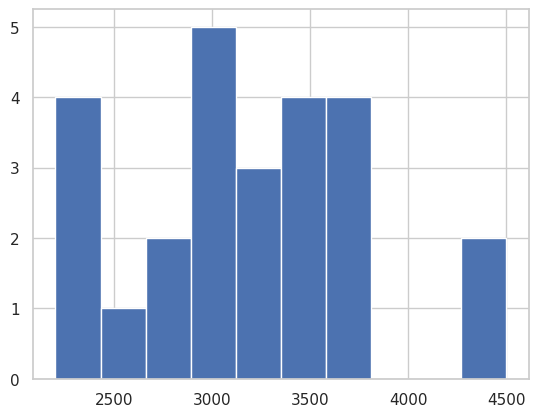

In [27]:
district_summary['predicted_yield_kg_ha'].hist()

In [28]:
district_summary['predicted_yield_kg_ha']

0     3526.937387
1     3794.546948
2     3716.970591
3     2288.736110
4     2200.021182
5     2256.882773
6     2426.140783
7     4500.602385
8     2677.864475
9     3063.239011
10    2984.350589
11    2688.958862
12    3215.165999
13    3522.978926
14    3649.777772
15    2644.254965
16    3377.229448
17    2959.908565
18    3255.325211
19    4324.917378
20    3012.585512
21    3775.500320
22    3396.221547
23    3070.902814
24    3325.970087
Name: predicted_yield_kg_ha, dtype: float64


📈 Visualization saved as 'yield_distribution_2026.png'

🔍 Diagnostic for District 4 (Lowest Yield):
Top 3 Drag Factors:
district_historical_avg   -968.799483
repro_efficiency          -645.419660
Season_ID                 -520.704122
dtype: float64


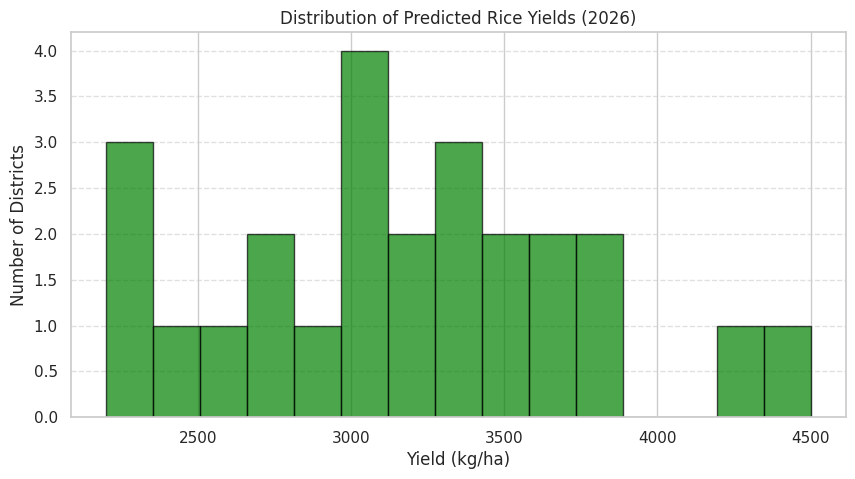

In [29]:
# ==========================================
# 6. VISUALIZATION & DIAGNOSTICS
# ==========================================
plt.figure(figsize=(10, 5))
plt.hist(district_summary['predicted_yield_kg_ha'], bins=15, color='green', alpha=0.7, edgecolor='black')
plt.title("Distribution of Predicted Rice Yields (2026)")
plt.xlabel("Yield (kg/ha)")
plt.ylabel("Number of Districts")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('yield_distribution_2026.png')

print("\n📈 Visualization saved as 'yield_distribution_2026.png'")

# Check Why low yields are occurring
low_dist_idx = district_summary['predicted_yield_kg_ha'].idxmin()
weights = pd.Series(lasso_yield_model.coef_, index=lasso_features)
impact = X_final_scaled[low_dist_idx] * weights
print(f"\n🔍 Diagnostic for District {district_summary.loc[low_dist_idx, 'District_ID']} (Lowest Yield):")
print("Top 3 Drag Factors:")
print(impact.sort_values().head(3))

📊 Mean of input features:
-0.1436191867156074

🧪 Raw Lasso Predictions (Before Clipping):
[2670.78036891 3532.50327363 3204.28171028 1449.752347   1546.23778719
 1656.51750073 1629.53815259 3503.40920155 2974.75563815 2451.10028063
 2526.02047404 2077.93751439 2812.08517673 3314.75767654 3259.3312448
 1999.67882832 2593.09789075 2304.99026078 2333.95514934 3930.34575966
 2353.5120091  3484.70376782 2656.04172787 2212.57042838 3005.51300935]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LassoCV was fitted with feature names
  warnings.warn(


(array([4., 0., 2., 4., 5., 1., 2., 3., 3., 1.]),
 array([1449.752347  , 1697.81168826, 1945.87102953, 2193.9303708 ,
        2441.98971206, 2690.04905333, 2938.1083946 , 3186.16773586,
        3434.22707713, 3682.2864184 , 3930.34575966]),
 <BarContainer object of 10 artists>)

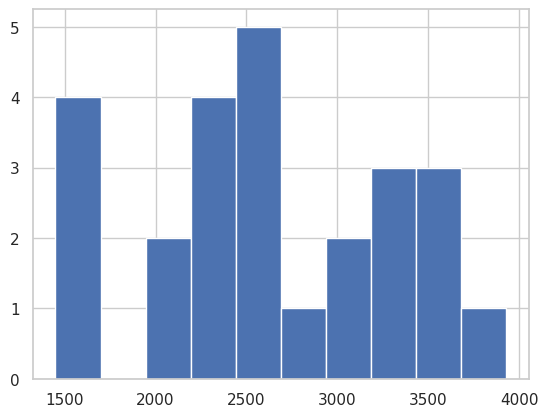

In [30]:
print("📊 Mean of input features:")
print(X_final_scaled.mean())

print("\n🧪 Raw Lasso Predictions (Before Clipping):")
raw_preds = lasso_yield_model.predict(X_final_scaled)
print(raw_preds)
plt.hist(raw_preds)

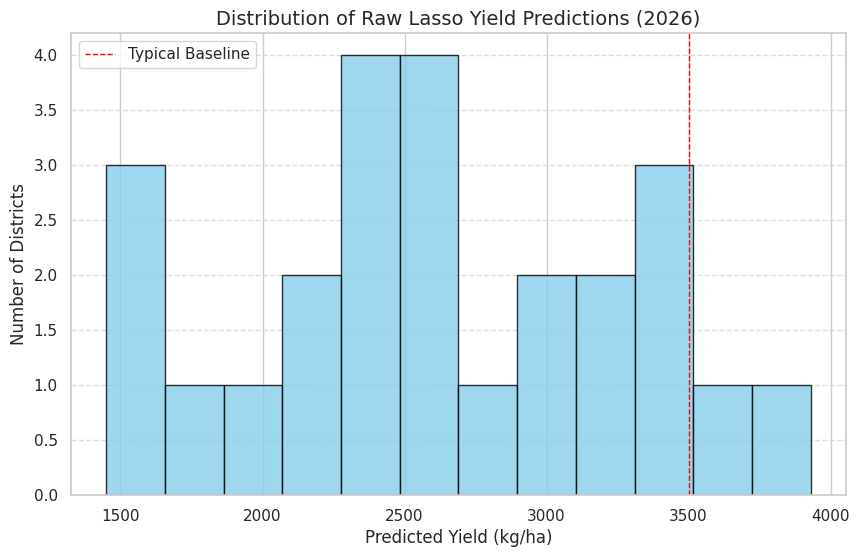

In [31]:
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(raw_preds, bins=12, color='skyblue', edgecolor='black', alpha=0.8)

# Add styling and labels
plt.title('Distribution of Raw Lasso Yield Predictions (2026)', fontsize=14)
plt.xlabel('Predicted Yield (kg/ha)', fontsize=12)
plt.ylabel('Number of Districts', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a vertical line for the national historical average (approx 3500)
plt.axvline(3500, color='red', linestyle='dashed', linewidth=1, label='Typical Baseline')
plt.legend()
plt.show()

# Get district yield reports and saving them

In [32]:
# 1. Create a clean mapping from your LSTM results
# This ensures District 0 maps to 'Ampara', etc.
name_mapping = df_lstm_results[['district_id', 'district']].drop_duplicates()

# 2. Merge the names into your summary
report_df = district_summary.copy()
report_df = report_df.merge(name_mapping, left_on='District_ID', right_on='district_id', how='left')

# 3. Calculate Gap and % Change
report_df['yield_gap_kg_ha'] = report_df['predicted_yield_kg_ha'] - report_df['district_historical_avg']
report_df['pct_change'] = (report_df['yield_gap_kg_ha'] / report_df['district_historical_avg']) * 100

# 4. Clean up and Rename for the final table
report_columns = {
    'district': 'District Name',
    'predicted_yield_kg_ha': 'Predicted Yield (kg/ha)',
    'district_historical_avg': 'Historical Avg (kg/ha)',
    'yield_gap_kg_ha': 'Yield Gap (kg/ha)',
    'pct_change': '% Change',
    'avg_health': 'Health Index (Z)',
    'heat_rain_ratio': 'Climate Stress Index'
}

# 5. Final Formatting
final_report = report_df[list(report_columns.keys())].rename(columns=report_columns)
final_report = final_report.round(2)

# Sort by lowest yield to see at-risk areas first
final_report = final_report.sort_values(by='Predicted Yield (kg/ha)', ascending=True)

# 6. Display
print("🌾 2026 SRI LANKA CROP YIELD FORECAST REPORT")
print("-" * 80)
print(final_report.to_string(index=False))

# Save for download
final_report.to_csv('Sri_Lanka_2026_Final_Report.csv', index=False)

🌾 2026 SRI LANKA CROP YIELD FORECAST REPORT
--------------------------------------------------------------------------------
District Name  Predicted Yield (kg/ha)  Historical Avg (kg/ha)  Yield Gap (kg/ha)  % Change  Health Index (Z)  Climate Stress Index
      Colombo                  2200.02                 2600.14            -400.12    -15.39              0.11                 -0.16
        Galle                  2256.88                 2616.14            -359.26    -13.73              0.12                 -0.19
   Batticaloa                  2288.74                 2822.71            -533.98    -18.92              0.08                 -0.11
      Gampaha                  2426.14                 2948.14            -522.00    -17.71              0.03                 -0.15
       Matale                  2644.25                 3067.43            -423.17    -13.80              0.02                 -0.25
       Jaffna                  2677.86                 2500.50             177.36  

In [33]:
print(pd.Series(lasso_yield_model.coef_, index=lasso_features))

veg_days                     -0.000000
repro_days                   -0.000000
peak_health                -110.839882
auc_health                  188.311497
avg_health                  155.742494
temp_flowering            -2537.746140
rain_flowering                0.000000
stress_flowering            -28.597645
PC1                         -26.061043
PC2                         -45.459965
PC3                          93.176016
PC4                         -22.129175
PC5                          34.825300
Season_ID                   614.189074
District_ID                 -13.374021
district_historical_avg     609.504413
heat_rain_ratio            2028.546228
repro_efficiency           -322.709830
crisis_year                -292.662881
dtype: float64


In [34]:
# 1. Quick Executive Summary
top_performers = final_report.sort_values('% Change', ascending=False).head(3)
at_risk = final_report.sort_values('% Change', ascending=True).head(3)

print("📝 EXECUTIVE SUMMARY")
print(f"✅ Most Resilient: {', '.join(top_performers['District Name'].tolist())}")
print(f"⚠️ Highest Risk: {', '.join(at_risk['District Name'].tolist())}")

# 2. National Average Prediction
national_avg_2026 = final_report['Predicted Yield (kg/ha)'].mean()
national_avg_hist = final_report['Historical Avg (kg/ha)'].mean()
national_drop = ((national_avg_2026 - national_avg_hist) / national_avg_hist) * 100

print(f"\n🌍 Estimated National Yield Change: {national_drop:.2f}%")

📝 EXECUTIVE SUMMARY
✅ Most Resilient: Jaffna, Kurunegala, Nuwara Eliya
⚠️ Highest Risk: Batticaloa, Gampaha, Mullaitivu

🌍 Estimated National Yield Change: -10.26%
